# Gaussian Mixture Models

Clusters modeled as Gaussian (normal) distributions

Assigns points to clusters with some probability

It is a generative model- once created, the model can be used to generate 'fake' data

## Gaussian (Normal) Distribution

Shit's a bell-curve

probability distribution:

$$
p(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-(\frac{x-\mu}{\sigma})^2}
$$

Where $\mu$ is the mean and $\sigma^2$ is the variance.

We have multiple numpy functions to draw points from $p(x)$:

np.random.randn ($\mu=0,\sigma = 1$)

np.random.normal ($\mu$ = loc, $\sigma$ = scale)

For a vector $x$:

$$
p(x) = \frac{1}{\sqrt{(2\pi)^n\det(\Sigma)}}e^{-\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)}
$$

Where $\Sigma$ is the covariance matrix.

We have the numpy function:

np.random.multivariate_normal (parameters mean vector, cov matrix)

## How to generate 2x2 positive definite matrices?

$$
\Sigma = Q[\lambda_1,0;0,\lambda_2]Q^T
$$

Where $\lambda_1,\lambda_2$ are the eigenvalues and $Q$ stores the orthonormal eigenvectors.

So, we select an orthonormal pair of vectors $q_1,q_2$, and a pair of positive number $\lambda_1,\lambda_2$, and jam em into the above form.

****

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## (2-dim) multivariate Gaussian distributions

In [2]:
def covariance_matrix(direction, eigenvalues):
    # builds 2x2 covariance matrices
    q1 = direction/np.linalg.norm(direction)
    q2 = np.array([q1[1],-q1[0]])
    
    # matrix Q
    Q = np.zeros((2,2))
    Q[:,0] = q1
    Q[:,1] = q2
    
    cov = Q.dot(np.diag(eigenvalues)).dot(Q.T)
    
    return cov

In [3]:
cov1 = covariance_matrix(direction=np.array([2,1]),eigenvalues=np.array([10,1]))

mean1 = np.array([0,0])

In [4]:
# draw points from the normal distribution
m = 100
X = np.random.multivariate_normal(mean=mean1,cov=cov1, size=m)

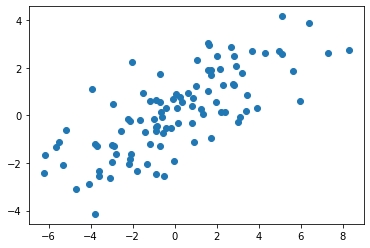

In [5]:
plt.scatter(X[:,0],X[:,1])

## Gaussian Mixture

### Definition

$$
p(x) = \sum_{i=1}^k\pi_i \mathcal{N}(x;\mu_i,\Sigma_i)
$$

With $0\leq \pi_i\leq 1$ and $\sum_{i=1}^k\pi_i=1$

And $\mathcal{N}(x;\mu_i,\Sigma_i)$ multivariate normal with mean $\mu_i$ and covariance matrix $\Sigma_i$.


### How do we sample from p(x)?

1. Select a Guassian distribution with probability $\pi_i$

2. Sample from the selected distribution 

****

In [6]:
cov2 = covariance_matrix(direction=np.array([2,3]),eigenvalues=np.array([2,4]))

cov3 = covariance_matrix(direction=np.array([1,5]),eigenvalues=np.array([10,6]))

mean2 = np.array([10,10])

mean3 = np.array([-10,-10])

In [7]:
k = 3 # number of clusters

pi = [0.7,0.05,0.25]

m = 5000

dist = np.random.choice(k,m,p=pi)

In [8]:
mean = [mean1, mean2, mean3]

cov = [cov1, cov2, cov3]

In [9]:
X = np.zeros((m,2))

for i in range(k):
    ni = np.sum(dist==i)
    X[dist==i] = np.random.multivariate_normal(mean=mean[i],cov=cov[i], size = ni)

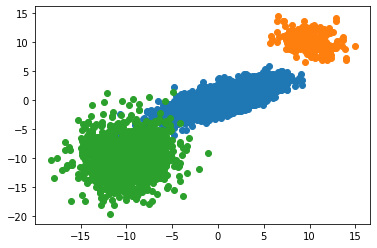

In [10]:
plt.scatter(X[dist ==0,0],X[dist==0,1])
plt.scatter(X[dist ==1,0],X[dist==1,1])
plt.scatter(X[dist ==2,0],X[dist==2,1])

## Estimating means and covariance matrices (k=1)

In [11]:
X = np.random.multivariate_normal(mean = mean1, cov = cov1, size = 1000)

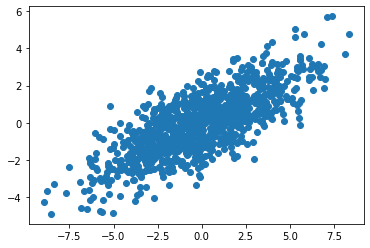

In [12]:
plt.scatter(X[:,0],X[:,1])

In [13]:
# maximum likelihood estimation

mu = np.mean(X,axis=0)

In [14]:
sig = np.cov(X)

****
## Expectation - Maximization (EM) Algorithm

Initialization: $\mu_1,\ldots,\mu_k,\Sigma_1,\ldots,\Sigma_k, \pi_1,\ldots,\pi_k$

E-step (expectation) : 

   Step 1: for each point $x_i$: compute $r_{ic}$ 'probability that our data point $x_i$ to cluster $c$'
    
   So $r_{ic} = \frac{\pi_C\mathcal{N}(x_i;\mu_c,\sigma_c)}{\sum_{j=1}^k \pi _j \mathcal{N}(x_i;\mu_j\sigma_j}  $
   
   Step 2: put each $r_{ic}$ in a matrix $R$, where $r_{i,j}= r_{ic}$
   
   Note that $R$ will be row-stochastic!
   
M-step (maximization) :

   For each cluster: compute

       $m_c = \sum_{i=1}^nr_{ic}$
       
       $\pi_c = m_c/m$
       
       $ \mu _c = 1/m_c \sum_{i=1}^m r_{ic}x_i $
       
       $ \Sigma_c = 1/m_c \sum_{i=1}^m r_{ic}(x_i-\mu_c)(x_i-\mu_c)^T$
       
Iterate Until Convergence

   convergence guaranteed *\\ I think this comes from being an em algorithm*
   
   initialization (often) important
      
      


In [15]:
def evaluate_normal_distribution(X,mean,cov):
    
    m,n = X.shape
    
    return np.exp(np.array([-0.5*(X[i]-mean).dot(np.linalg.inv(cov).dot(X[i]-mean)) 
                     for i in range(m)]))/np.sqrt((2*np.pi)**n*np.linalg.det(cov))
    

In [16]:
def sample_gaussian_mixture(m,cov,mean,pi):
    k = len(mean) # number of gaussian distributions
    dist = np.random.choice(k,m,p=pi) # distributions
    X = np.zeros((m,2))
    for i in range(k):
        ni = np.sum(dist==i) # number of points from dist. i
        X[dist==i] = np.random.multivariate_normal(mean = mean[i], cov = cov[i], size=ni)
    return X

In [17]:
# toy example:

#  dist. probabilities
pi = [0.6,0.2,0.2]
# means
mean1 = np.array([2,2])
mean2 = np.array([-2,-2])
mean3 = np.array([2,-2])
mean = [mean1,mean2,mean3]
# covariance matrices
cov1 = covariance_matrix(direction=[2,1],eigenvalues=[1,.2])
cov2 = covariance_matrix(direction=[0,1],eigenvalues=[0.1,0.1])
cov3 = covariance_matrix(direction=[1,0],eigenvalues=[2,0.2])
cov = [cov1,cov2,cov3]

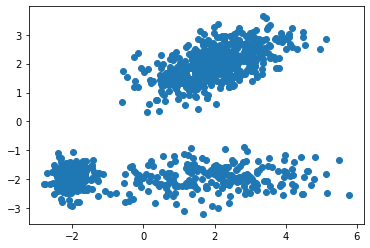

In [18]:
# sample from the distribution

m = 1000
X = sample_gaussian_mixture(m,cov,mean,pi)
plt.scatter(X[:,0],X[:,1])

In [30]:
def em(X,k,max_iter=100):
    'expectation-maximiation algorithm'
    
    m,n = X.shape
    
    # initializations
    
    cov = [np.eye(n) for i in range(k)]
    #mean = X[np.random.choice(m,k), replace = False]
    # greedy means
    mean = np.zeros((k,n))
    mean[0] = X[np.random.choice(m,1)]
    
    from sklearn.metrics import pairwise_distances
    
    for i in range(1,k):
        dist = np.sum(pairwise_distances(X,mean[0:i]), axis = 1)
        mean[i] = X[np.argmax(dist)]
    
    pi = [1/k for i in range(k)]
    
    # initialize R matrix
    
    R = np.zeros((m,k))
    
    # EM iterations
    for it in range(max_iter):
        # e-step
        for i in range(k):
            R[:,i] = evaluate_normal_distribution(X,mean[i],cov[i])
        R = R*pi
        R = R/np.sum(R, axis =1,keepdims=True) # this is kind of a tricky thing with numpy
        # m-step
        mc = np.sum(R,axis=0)
        pi = mc/m
        for i in range(k):
            mean[i] = np.average(X,axis=0,weights=R[:,i])
            cov[i] = np.cov(X,rowvar=False,aweights=R[:,i])
            
    return cov, mean, pi

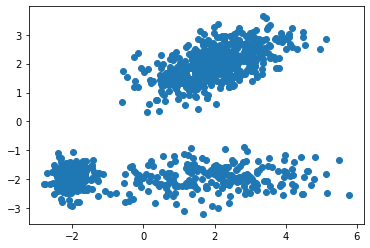

In [28]:
plt.scatter(X[:,0],X[:,1])

In [31]:
cov,mean,pi = em(X,k=3)

In [34]:
def plot_log_probability_distribution(X,cov,mean,pi):
    
    """
    this function plots:
        - level curves of the proba. distribution (negative logarithm)
        - cluster means
        - cluster boundaries
    """
    
    from matplotlib.colors import LogNorm  
    resolution = 500
    
    # number of clusters
    k = len(pi)
    
    # create a mesh grid
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    points = np.c_[xx.ravel(), yy.ravel()]
    Rpoints = np.zeros((resolution**2,k))
    for i in range(k):
        Rpoints[:,i] = evaluate_normal_distribution(points,mean[i],cov[i])
    # multiply by cluster probabilities pi
    Rpoints = Rpoints*pi
    # sum along columns
    prob = -np.log(np.sum(Rpoints,axis=1).reshape(xx.shape))
    # cluster prediction
    pred = np.argmax(Rpoints,axis=1).reshape(xx.shape)

    plt.contourf(xx, yy, prob,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                     levels=np.logspace(0, 2, 12))

    plt.contour(xx, yy, prob,linewidths=1,colors='black',
               norm=LogNorm(vmin=1.0, vmax=30.0),
                     levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, pred,
                    linewidths=2, colors='r', linestyles='dashed')
    # plot means
    for i in range(k):
        plt.scatter(mean[i][0],mean[i][1],
                    marker='o', s=20, linewidths=8,
                    color='w', zorder=10, alpha=0.9)
        plt.scatter(mean[i][0],mean[i][1],
                    marker='x', s=50, linewidths=2,
                    color='r', zorder=11, alpha=1)

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plt.colorbar()
    plt.title('log probability distribution')

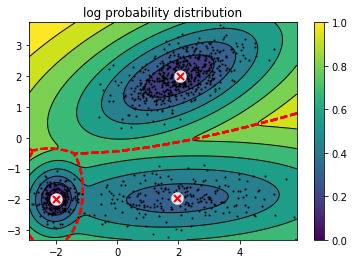

In [35]:
plot_log_probability_distribution(X,cov,mean,pi)

In [38]:
def cluster_probabilities(X,cov,mean,pi):
    m,n = X.shape
    k = len(pi)
    # build matrix R
    R = np.zeros((m,k))
    for i in range(k):
        R[:,i] = evaluate_normal_distribution(X,mean[i],cov[i])
    R = R*pi
    # normalize rows
    
    R = R/np.sum(R,axis=1,keepdims=True)
    return R

In [39]:
def cluster_prediction(X,cov,mean,pi):
    R = cluster_probabilities(X,cov,mean,pi)
    clusters = np.argmax(R,axis = 1)
    return clusters

In [40]:
newX = np.array([[1,-2],[2,0],[-2,-3]])

In [41]:
cluster_probabilities(newX,cov,mean,pi).round(2)


array([[0.  , 0.  , 1.  ],
       [0.94, 0.  , 0.06],
       [0.  , 0.94, 0.06]])

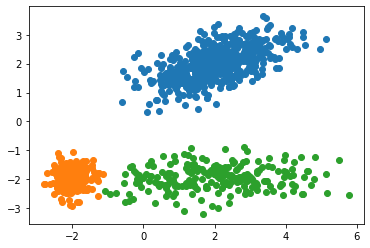

In [44]:
cluster = cluster_prediction(X,cov,mean,pi)
for i in range(k):
    plt.scatter(X[cluster==i,0],X[cluster==i,1])

## Irises and Penguins Revisited


In [45]:
import pandas as pd

In [46]:
# load the iris dataset
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice-bis/master/Data/iris.csv'
data = pd.read_csv(url)
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [47]:
X = data[['sepal_length','sepal_width','petal_length','petal_width']].to_numpy()

In [48]:
k = 3
cov,mean,pi = em(X,k)

In [49]:
clusters = cluster_prediction(X,cov,mean,pi)

In [52]:
# cluster 0

data[clusters==0].species.value_counts()

Iris-versicolor    45
Name: species, dtype: int64

In [53]:
# cluster 1

data[clusters==1].species.value_counts()

Iris-virginica     50
Iris-versicolor     5
Name: species, dtype: int64

In [54]:
# cluster 2

data[clusters==2].species.value_counts()

Iris-setosa    50
Name: species, dtype: int64

In [56]:


# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/penguins_size.csv'
data = pd.read_csv(url)
data.dropna(inplace=True)
data



,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [59]:
X = data[['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']].to_numpy()

X = X/np.max(np.abs(X),axis=0)

In [70]:
k = 3
cov,mean,pi = em(X,k)

In [71]:
clusters = cluster_prediction(X,cov,mean,pi)

In [72]:
# cluster 0

data[clusters==0].species.value_counts()

Chinstrap    65
Adelie        2
Name: species, dtype: int64

In [73]:
# cluster 1

data[clusters==1].species.value_counts()

Gentoo    120
Name: species, dtype: int64

In [74]:
# cluster 2

data[clusters==2].species.value_counts()

Adelie       144
Chinstrap      3
Name: species, dtype: int64